In [ ]:
# --- 0. MASTER CONFIG & CLEANING ---
# This block is necessary to make sure all the other code blocks run properly. It does a basic cleanup of the raw input data.

# Feb 20 Note: I've been testing removing individual variables as well that appear to have low impact on
# the overall clusters (low component loadings and CV). So far removing QNATAM and QUNOCCHU increases 
# silhouette score and explined variance. I've dropped QGROUP altogether because it was a stand-in for nursing 
# homes and the margins of error are just way too massive.

sovi_vars = [
    "QPOVTY", "QCVLUN", "QED12LES", "QFHH", "QESL", "QAGEDEP", "QFEMALE",
    "QFEMLBR", "QRICH", "QSERV", "QEXTRCT", "QMOHO", "QNOAUTO",
    "MDGRENT", "MDHSEVAL", "PPUNIT", "QRENTER", "QSSBEN", "QHSEBRDN",
    "MEDAGE", "PERCAP", "QBLACK", "QASIAN", "QHISP", "QFAM", "QNOHLTH"
]

def apply_purge(dataframe, var_list):
    """Standardized cleaning to fix -999s and negative artifacts across all blocks"""
    d = dataframe.copy()
    # Fix placeholders
    d = d.replace({-999: np.nan, -999.0: np.nan})
    # Clip negative artifacts (the -0.0292 issue)
    for col in var_list:
        if col in d.columns:
            d.loc[d[col] < 0, col] = 0
    # Drop zero population
    d = d[d['Total_Pop'] > 0]
    return d

# Use this as the reference so sovi_vars never shrinks during testing
master_sovi_list = sovi_vars.copy()

In [4]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

# This can replicate my original*, unscaled k-means results and compare them to properly scaled results. 
# Right now, none of the data is actually exported, and I'm only showing one year at a time.

# The rest of the code blocks are sequential attempts to improve the silhouette scores and explained variance of the scaled results, i.e., create
# more distinct and effective clusters.


# * The results will actually be slightly different because there were some problems in the original dataset due to user error. Some years pulled the
# wrong ACS tables. There are not any major issues in my original thesis results, just some inconsistencies that I've fixed since then. 


# --- 1. DATA PREP ---
year = 2010
raw_df = pd.read_csv(f'../data/yearly_data/{year}.csv')

# Use global purge and copy master list
df = apply_purge(raw_df, sovi_vars)
current_vars = sovi_vars.copy()
df_vars = df[current_vars]

# Impute raw values (if any)
data_imputed = KNNImputer(n_neighbors=5).fit_transform(df_vars)
data_scaled = StandardScaler().fit_transform(data_imputed)

# --- 2. TESTING LOOP ---
# u = unscaled, s = scaled

combined_results = []
tss_u = np.sum((data_imputed - np.mean(data_imputed, axis=0))**2)
tss_s = np.sum((data_scaled - np.mean(data_scaled, axis=0))**2)

for k in range(2, 11):
    # --- Unscaled ---
    km_u = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(data_imputed)
    sil_u = silhouette_score(data_imputed, km_u.labels_)
    ev_u = 1 - (km_u.inertia_ / tss_u)
    ch_u = calinski_harabasz_score(data_imputed, km_u.labels_)
    db_u = davies_bouldin_score(data_imputed, km_u.labels_)

    # --- Scaled ---
    km_s = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(data_scaled)
    sil_s = silhouette_score(data_scaled, km_s.labels_)
    ev_s = 1 - (km_s.inertia_ / tss_s)
    ch_s = calinski_harabasz_score(data_scaled, km_s.labels_)
    db_s = davies_bouldin_score(data_scaled, km_s.labels_)

    combined_results.append({
        'k': k, 
        'U_Sil': sil_u, 'U_CH': ch_u, 'U_DB': db_u, 'U_EV': ev_u,
        'S_Sil': sil_s, 'S_CH': ch_s, 'S_DB': db_s, 'S_EV': ev_s
    })

df_res = pd.DataFrame(combined_results)
print(f"--- K-Means Comprehensive Metrics: Year {year} ---")
print(df_res.round(4))

--- K-Means Comprehensive Metrics: Year 2010 ---
    k   U_Sil       U_CH    U_DB    U_EV   S_Sil      S_CH    S_DB    S_EV
0   2  0.7261  2233.8285  0.5721  0.6017  0.1402  277.6619  2.0747  0.1581
1   3  0.5769  2703.9416  0.5796  0.7854  0.1920  319.3062  1.7018  0.3017
2   4  0.5679  3378.3444  0.5316  0.8728  0.2021  280.0221  1.8263  0.3626
3   5  0.5588  3708.9155  0.5488  0.9095  0.1500  250.9349  1.8216  0.4048
4   6  0.5589  3800.1711  0.5083  0.9280  0.1270  225.3874  1.8503  0.4331
5   7  0.5142  4801.9667  0.5241  0.9513  0.1041  204.3853  1.9048  0.4541
6   8  0.5070  5378.7401  0.5386  0.9624  0.1139  186.5668  2.0156  0.4699
7   9  0.5052  5124.7710  0.5704  0.9653  0.1116  172.9434  1.9510  0.4845
8  10  0.4918  5925.6673  0.5708  0.9732  0.1101  162.7314  1.9095  0.4989


In [26]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mstats

# This version uses a combined method where PCA is first used to reduce the dimensions, then the clusters are created based on those factors.

# It also includes two data cleaning steps, winsorization and coefficient of variance filtering, meant to marginally increase silhouette score and EV.
    # These can be toggled on and off.


# --- 1. CONFIG & DATA PREP ---
year = 2010
run_cv = True       # Toggle CV filtering
cv_threshold = 0.10
run_winsor = True   # Toggle Winsorization
raw_df = pd.read_csv(f'../data/yearly_data/{year}.csv')

df = apply_purge(raw_df, sovi_vars)
current_vars = sovi_vars.copy()
df_vars = df[current_vars].copy()

# --- 2. WINSORIZATION ---
if run_winsor:
    for col in current_vars:
        mask = df_vars[col].notnull()
        if mask.any():
            df_vars.loc[mask, col] = mstats.winsorize(df_vars.loc[mask, col], limits=[0.05, 0.05])
    print("Winsorization applied.")
else:
    print("Winsorization bypassed.")

# Imputation
data_imputed = KNNImputer(n_neighbors=5).fit_transform(df_vars)
df_imputed_raw = pd.DataFrame(data_imputed, columns=current_vars)

# --- 3. CV VARIABLE FILTERING ---
if run_cv:
    temp_scaled = StandardScaler().fit_transform(data_imputed)
    temp_km = KMeans(n_clusters=4, random_state=42, n_init='auto').fit(temp_scaled)
    c_means = df_imputed_raw.groupby(temp_km.labels_).mean()
    cv_scores = c_means.std() / df_imputed_raw.mean().abs()
    
    selected_vars = cv_scores[cv_scores > cv_threshold].index.tolist()
    print(f"Dropped via CV: {cv_scores[cv_scores <= cv_threshold].index.tolist()}")
else:
    selected_vars = current_vars
    print("CV filtering bypassed.")

# --- 4. PCA REDUCTION ---
data_final_scaled = StandardScaler().fit_transform(df_imputed_raw[selected_vars])
pca = PCA(n_components=4)
data_pca = pca.fit_transform(data_final_scaled)

print(f"Total Explained Variance (PCA): {np.sum(pca.explained_variance_ratio_):.2%}")

# --- 5. K-MEANS TESTING LOOP ---
testing_results = []
tss_pca = np.sum((data_pca - np.mean(data_pca, axis=0))**2)

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = kmeans.fit_predict(data_pca)
    
    # Calculate Metrics
    sil = silhouette_score(data_pca, labels)
    ch = calinski_harabasz_score(data_pca, labels) # Higher is better
    db = davies_bouldin_score(data_pca, labels)    # Lower is better
    ev = 1 - (kmeans.inertia_ / tss_pca)           # Explained Variance
    
    testing_results.append({
        'k': k,
        'Silhouette': sil,
        'CH_Score': ch,
        'DB_Index': db,
        'EV': ev
    })

print("\nPCA-Based K-Means Results:")
results_df = pd.DataFrame(testing_results)
print(results_df.round(4))

Winsorization applied.
Dropped via CV: ['QAGEDEP', 'QFEMALE', 'QFEMLBR', 'PPUNIT']
Total Explained Variance (PCA): 72.44%

PCA-Based K-Means Results:
    k  Silhouette  CH_Score  DB_Index      EV
0   2      0.3626  771.7980    1.2003  0.3429
1   3      0.3638  951.3353    0.9955  0.5628
2   4      0.3841  947.8870    1.0301  0.6581
3   5      0.3093  900.0771    1.0887  0.7092
4   6      0.3136  874.1266    1.0936  0.7477
5   7      0.3087  827.2793    1.0626  0.7710
6   8      0.3041  757.9758    1.1951  0.7827
7   9      0.2992  719.4425    1.1856  0.7963
8  10      0.2714  685.7831    1.2146  0.8075


In [ ]:
# Feb 20 Note: It seems like this is a more effective method than my nested clusters. Just need to better
# justify the choice of K. See additional notes below.

In [42]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mstats

# I noticed during all the other steps that the optimal number of clusters is usually quite low. I don't like using a low number of clusters
# because I feel it removes some of the explanatory power of using clusters. Using 3 essentially just splits everything into high, medium, and low
# vulnerability. This might be the most mathematically optimal solution, but it doesn't have as much qualitative meaning.

# My solution to address this mismatch was to first create a smaller number of "parent clusters" capture the basic structure of vulnerability across
# the data, and then create "sub clusters" based on those parents for greater detail. This lets me have, say, 6 clusters that have higher silhouette
# scores and explained variance than if I had simply done k-mean with k=6.


# --- 1. CONFIG & DATA PREP ---
year = 2010

run_cv = True       # Toggle CV filtering
cv_threshold = 0.10
run_winsor = True   # Toggle Winsorization
raw_df = pd.read_csv(f'../data/yearly_data/{year}.csv')

df = apply_purge(raw_df, sovi_vars)
current_vars = sovi_vars.copy()
df_vars = df[current_vars].copy()

# --- 2. PREPROCESSING ---
if run_winsor:
    for col in current_vars:
        mask = df_vars[col].notnull()
        if mask.any():
            df_vars.loc[mask, col] = mstats.winsorize(df_vars.loc[mask, col], limits=[0.05, 0.05])

data_imputed = KNNImputer(n_neighbors=5).fit_transform(df_vars)
df_raw = pd.DataFrame(data_imputed, columns=current_vars)

if run_cv:
    temp_scaled = StandardScaler().fit_transform(data_imputed)
    km_cv = KMeans(n_clusters=4, random_state=42, n_init='auto').fit(temp_scaled)
    cv_scores = df_raw.groupby(km_cv.labels_).mean().std() / df_raw.mean().abs()
    selected_vars = cv_scores[cv_scores > cv_threshold].index.tolist()
    print(f"Variables dropped: {cv_scores[cv_scores <= cv_threshold].index.tolist()}\n")
else:
    selected_vars = current_vars

data_scaled = StandardScaler().fit_transform(df_raw[selected_vars])

# --- 3. PCA & PARENT CLUSTERING ---
# Define number of parent and sub clusters
parent_k, sub_k = 3, 2    
 
data_pca = PCA(n_components=4).fit_transform(data_scaled)
kmeans_parent = KMeans(n_clusters=parent_k, n_init='auto', random_state=42)
df['parent_cluster'] = kmeans_parent.fit_predict(data_pca)

ev_p = 1 - (kmeans_parent.inertia_ / np.sum((data_pca - np.mean(data_pca, axis=0))**2))
print(f"--- PARENT LEVEL (k={parent_k}) ---\nEV: {ev_p:.2%} | Silhouette: {silhouette_score(data_pca, df['parent_cluster']):.4f}\n")

# --- 4. SUB-PARENT CLUSTERING ---
df['sub_cluster'] = df['parent_cluster'].astype(str)
sub_results = []

for p_id in range(parent_k):
    mask = (df['parent_cluster'] == p_id)
    sub_data = data_pca[mask]
    
    if len(sub_data) >= sub_k:
        km_sub = KMeans(n_clusters=sub_k, n_init='auto', random_state=42)
        df.loc[mask, 'sub_cluster'] = [f"{p_id}-{s}" for s in km_sub.fit_predict(sub_data)]
        ev_s = 1 - (km_sub.inertia_ / np.sum((sub_data - np.mean(sub_data, axis=0))**2))
        sub_results.append({'Parent': p_id, 'Sub_EV': ev_s, 'N': len(sub_data)})

print("--- SUB-PARENT METRICS ---")
print(pd.DataFrame(sub_results))


Variables dropped: ['QAGEDEP', 'QFEMALE', 'QFEMLBR', 'PPUNIT']

--- PARENT LEVEL (k=3) ---
EV: 56.28% | Silhouette: 0.3638

--- SUB-PARENT METRICS ---
   Parent    Sub_EV    N
0       0  0.376869  396
1       1  0.296910  680
2       2  0.412465  405


In [43]:
import pandas as pd
import numpy as np
import os
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mstats

# This version calculates everything based on the entire pooled dataset from 2010 to 2019. It marginally improves silhouette and EV, but
# also has the added benefit of making comparisons over time more stable. 


# --- 1. CONFIG & POOLING ---
years = range(2010, 2020)
parent_k, sub_k = 3, 2
run_cv = True 
cv_threshold = 0.11
run_winsor = True 

raw_list = []
for yr in years:
    path = f'../data/yearly_data/{yr}.csv'
    if os.path.exists(path):
        temp = pd.read_csv(path)
        temp['Year'] = yr
        raw_list.append(temp)

# Purge and prep variables
pool_df = apply_purge(pd.concat(raw_list, ignore_index=True), sovi_vars)
current_vars = sovi_vars.copy()
df_vars = pool_df[current_vars].copy()

# --- 2. PREPROCESSING (TOGGLEABLE) ---
if run_winsor:
    for col in current_vars:
        mask = df_vars[col].notnull()
        if mask.any():
            df_vars.loc[mask, col] = mstats.winsorize(df_vars.loc[mask, col], limits=[0.05, 0.05])

data_imputed = KNNImputer(n_neighbors=5).fit_transform(df_vars)
df_raw = pd.DataFrame(data_imputed, columns=current_vars)

if run_cv:
    temp_scaled = StandardScaler().fit_transform(data_imputed)
    km_cv = KMeans(n_clusters=4, random_state=42, n_init='auto').fit(temp_scaled)
    cv_scores = df_raw.groupby(km_cv.labels_).mean().std() / df_raw.mean().abs()
    selected_vars = cv_scores[cv_scores > cv_threshold].index.tolist()
    print(f"Dropped: {cv_scores[cv_scores <= cv_threshold].index.tolist()}\n")
else:
    selected_vars = current_vars

data_scaled = StandardScaler().fit_transform(df_raw[selected_vars])

# --- 3. PCA & PARENT CLUSTERING ---
data_pca = PCA(n_components=4).fit_transform(data_scaled)
km_p = KMeans(n_clusters=parent_k, n_init='auto', random_state=42)
pool_df['parent_cluster'] = km_p.fit_predict(data_pca)

ev_p = 1 - (km_p.inertia_ / np.sum((data_pca - np.mean(data_pca, axis=0))**2))
sil_p = silhouette_score(data_pca, pool_df['parent_cluster'], sample_size=10000)

print(f"--- POOLED PARENT LEVEL ---\nEV: {ev_p:.2%} | Sil: {sil_p:.4f}\n")

# --- 4. SUB-PARENT CLUSTERING ---
pool_df['sub_cluster'] = pool_df['parent_cluster'].astype(str)
sub_results = []

for p_id in range(parent_k):
    mask = (pool_df['parent_cluster'] == p_id)
    sub_data = data_pca[mask]
    
    if len(sub_data) >= sub_k:
        km_s = KMeans(n_clusters=sub_k, n_init='auto', random_state=42)
        pool_df.loc[mask, 'sub_cluster'] = [f"{p_id}-{s}" for s in km_s.fit_predict(sub_data)]
        ev_s = 1 - (km_s.inertia_ / np.sum((sub_data - np.mean(sub_data, axis=0))**2))
        sub_results.append({'Parent': p_id, 'Sub_EV': ev_s, 'N': len(sub_data)})

print("--- POOLED SUB-PARENT METRICS ---")
print(pd.DataFrame(sub_results))

overall_sil = silhouette_score(data_pca, pool_df['sub_cluster'], sample_size=10000)
print(f"\nOverall Nested Silhouette Score: {overall_sil:.4f}")

Dropped: ['QAGEDEP', 'QFEMALE', 'QFEMLBR', 'PPUNIT']

--- POOLED PARENT LEVEL ---
EV: 56.53% | Sil: 0.3662

--- POOLED SUB-PARENT METRICS ---
   Parent    Sub_EV     N
0       0  0.365586  3852
1       1  0.391455  3959
2       2  0.290807  6999

Overall Nested Silhouette Score: 0.2525


In [ ]:
# Feb 20 note: It looks like my theory about the nested clusters isn't really panning out, given the
# overall nested silhouette.
# Silhouette scores and EV are higher when just clustering on the components (see other Feb 20 note above).

# But maybe this is a worthy trade off for interpretability? Since 0.25 silhouette score is still 
# "decent" structure? EV is still low compared to the other method, though.

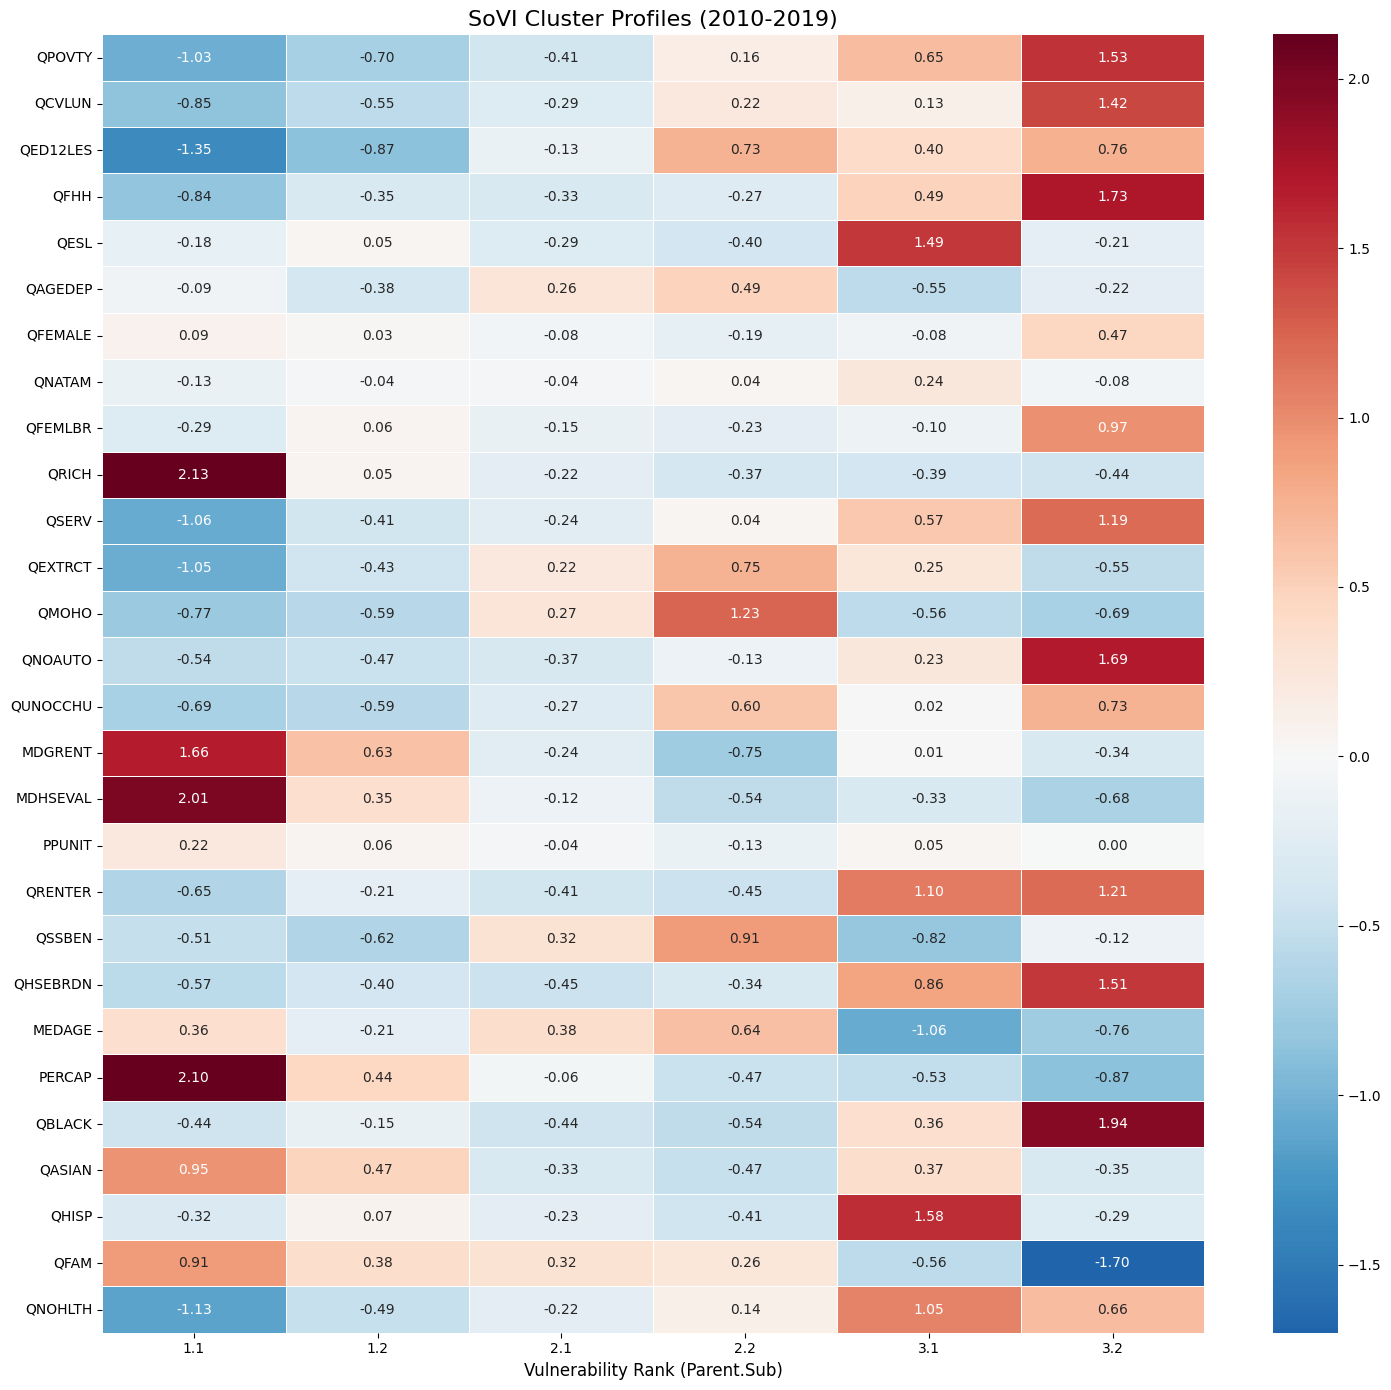

SUCCESS: ../data/yearly_tracts_processed/K-sovi_2010.gpkg
SUCCESS: ../data/yearly_tracts_processed/K-sovi_2011.gpkg
SUCCESS: ../data/yearly_tracts_processed/K-sovi_2012.gpkg
SUCCESS: ../data/yearly_tracts_processed/K-sovi_2013.gpkg
SUCCESS: ../data/yearly_tracts_processed/K-sovi_2014.gpkg
SUCCESS: ../data/yearly_tracts_processed/K-sovi_2015.gpkg
SUCCESS: ../data/yearly_tracts_processed/K-sovi_2016.gpkg
SUCCESS: ../data/yearly_tracts_processed/K-sovi_2017.gpkg
SUCCESS: ../data/yearly_tracts_processed/K-sovi_2018.gpkg
SUCCESS: ../data/yearly_tracts_processed/K-sovi_2019.gpkg


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd

# This version finalizes everything I have so far by sorting the clusters from low to high vulnerability. This is based on just their poverty rate,
# meaning there may be more elegant or rigorous ways to do this. 

# It also maps the variables as z-scores for quick comparison between the clusters. Additionally, variables that were dropped based on the CV filter
# are added back in so that they can be included in profile analysis. They were removed from the clustering process in order to create more well-defined
# clusters, but are still present in the overall database.


# Feb 20. Note: This applies to the nested clusters, which may not be the most effective in reality.


# --- 1. RANK PARENT CLUSTERS ---
# Find parent order by mean poverty
p_rank_idx = pool_df.groupby('parent_cluster')['QPOVTY'].mean().sort_values().index
p_map = {old: i + 1 for i, old in enumerate(p_rank_idx)}

# --- 2. RANK SUB-CLUSTERS WITHIN PARENTS ---
rank_map = {}
for p_old, p_new in p_map.items():
    # Get sub-clusters belonging to this parent
    subs = pool_df[pool_df['parent_cluster'] == p_old]['sub_cluster'].unique()
    
    # Sort these specific sub-clusters by poverty
    s_rank_idx = pool_df[pool_df['sub_cluster'].isin(subs)].groupby('sub_cluster')['QPOVTY'].mean().sort_values().index
    
    # Create label: "ParentRank.SubRank" (e.g., 1.1, 1.2)
    for i, s_old in enumerate(s_rank_idx):
        rank_map[s_old] = f"{p_new}.{i+1}"

# --- 3. APPLY TO DATAFRAME ---
final_df = pool_df.copy()
final_df['vulnerability_rank'] = final_df['sub_cluster'].map(rank_map)

# --- 4. PREP HEATMAP DATA (SWITCHED TO ALL VARIABLES) ---
profiles = final_df.groupby('vulnerability_rank')[current_vars].mean()

# Standardize to Z-Scores using the full variable list
z_profiles = (profiles - final_df[current_vars].mean()) / final_df[current_vars].std()

# Ensure the index sorts numerically (1.1, 1.2, 2.1)
z_profiles.index = pd.to_numeric(z_profiles.index)
z_profiles = z_profiles.sort_index()

# --- 5. PLOTTING ---
plt.figure(figsize=(15, 14)) # Slightly taller to accommodate more variables
sns.heatmap(z_profiles.T, 
            cmap='RdBu_r', 
            center=0, 
            annot=True, 
            fmt=".2f", 
            linewidths=.5)

plt.title(f"SoVI Cluster Profiles ({years.start}-{years.stop-1})", fontsize=16)
plt.xlabel("Vulnerability Rank (Parent.Sub)", fontsize=12)
plt.tight_layout()
plt.show()

# --- 6. FINAL EXPORT ---

for year in range(2010, 2020):

    # 1. Load the geometry fresh
    geo_source = gpd.read_file("../data/tracts2010.gpkg")

    # 2. Force string types to prevent the 'str and int64' ValueError
    geo_source['GEOID'] = geo_source['GEOID'].astype(str)
    final_df['GEOID'] = final_df['GEOID'].astype(str)

    # 3. Create a clean lookup (1 row per tract)
    # This ensures we only bring over the rank and cluster ID
    rank_lookup = final_df[['GEOID', 'vulnerability_rank', 'sub_cluster']].drop_duplicates('GEOID')

    # 4. Merge
    final_map = geo_source.merge(rank_lookup, on='GEOID', how='left')

    # 5. Define path and save
    output_dir = "../data/yearly_tracts_processed"
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"K-sovi_{year}.gpkg")

    try:
        if os.path.exists(output_path):
            os.remove(output_path)
        
        # Save to file
        final_map.to_file(output_path, driver="GPKG")
        print(f"SUCCESS: {output_path}")
    except Exception as e:
        print(f"FAIL: {e}")

--- Multicollinearity Test ---
    Variable        VIF
18    PERCAP  12.786609
6      QRICH   5.691285
13  MDHSEVAL   5.270666
0     QPOVTY   5.256865
14   QRENTER   4.271585
4       QESL   4.065310
2   QED12LES   4.005183
3       QFHH   3.925352
19    QBLACK   3.824391
17    MEDAGE   3.820870
22      QFAM   3.582153
15    QSSBEN   3.485754
10   QNOAUTO   3.470345
21     QHISP   3.445232
16  QHSEBRDN   3.287156
12   MDGRENT   2.974837
9      QMOHO   2.817393
23   QNOHLTH   2.486142
1     QCVLUN   2.075428
8    QEXTRCT   1.988619
7      QSERV   1.952648
20    QASIAN   1.784117
11  QUNOCCHU   1.645252
5     QNATAM   1.030161


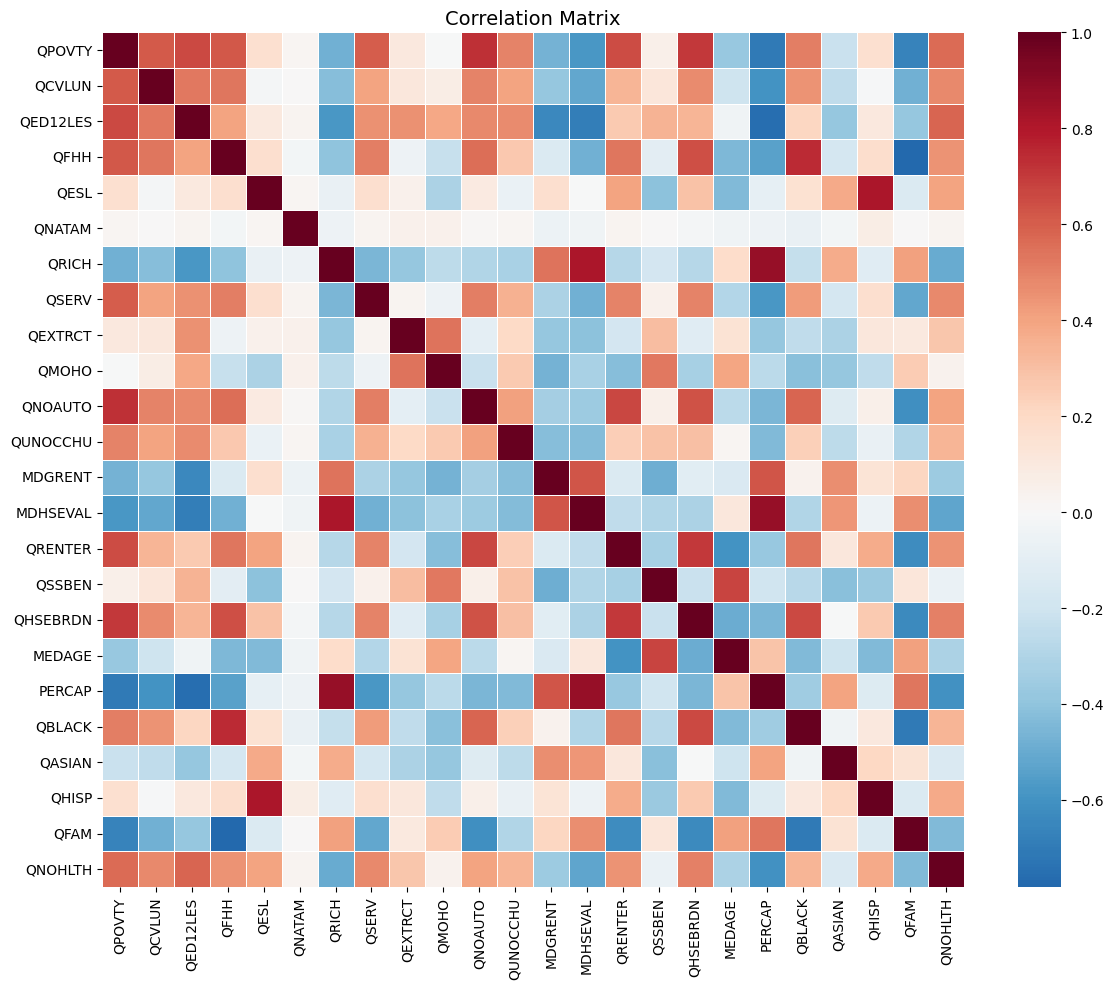

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Finally, for now, this block just checks for multicollinearity and shows the correlation matrix.


# --- 1. PREP SCALED DATA ---
X_vif = pd.DataFrame(data_scaled, columns=selected_vars)

# --- 2. CALCULATE VIF ---
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# Sort results
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print("--- Multicollinearity Test ---")
print(vif_data)

# --- 3. CORRELATION HEATMAP ---
plt.figure(figsize=(12, 10))
sns.heatmap(X_vif.corr(), 
            annot=False, 
            fmt=".2f", 
            cmap='RdBu_r', 
            center=0, 
            linewidths=.5)

plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()